# Modèle de Deep Learning : ResNet_101V2

Les modèles de deep learning sont entraînés directement à partir des images.

Afin de garantir une comparaison équitable avec les autres modèles de deep
learning du projet, les mêmes jeux de données sont utilisés :

- `train_augmented` pour l’entraînement ;
- `validation` pour la validation ;
- `test` pour l’évaluation finale.

Aucune nouvelle augmentation d’images ne sera appliquée dans le modèle,
puisque le jeu `train_augmented` contient déjà les images augmentées communes
aux différents modèles.

L'intégrité des données à été vérifiée dans le notebook du modèle `ResNet50` avec correction du déséquilibre.

Aucune correction supplémentaire de poids n'est réalisée ici.

Par rapport à ResNet50 , ResNet101V2 est:

- plus profond : environ 44,7 millions de paramètres contre 25,6 millions
- la version V2 utilise des blocs résiduels dits de pré-activation, conçus pour faciliter l’optimisation des réseaux profonds
- dans les références Keras, ResNet101V2 obtient de meilleures performances ImageNet que ResNet50 et ResNet50V2, tout en restant beaucoup moins lourd que ResNet152V2.

# Préparation

## Environnement de travail

In [1]:
# Imports et configuration générale

from pathlib import Path
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Graine utilisée pour améliorer la reproductibilité
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Imports réalisés avec succès.")
print("Seed :", SEED)

I0000 00:00:1784541518.634226 1413686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784541518.919702 1413686 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784541521.139653 1413686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Imports réalisés avec succès.
Seed : 42


In [2]:
# Vérification gpu

print("=" * 70)
print("Python :", sys.executable)
print("TensorFlow :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "Aucun GPU détecté. Vérifie que le kernel sélectionné est "
        "'Python (Covid19_gpu)'."
    )

print("GPU détecté(s) :", gpus)

for gpu in gpus:
    details = tf.config.experimental.get_device_details(gpu)
    print(
        "Nom du GPU :",
        details.get("device_name", gpu.name)
    )

print("=" * 70)

Python : /home/noura/miniforge3/envs/Covid19_gpu/bin/python
TensorFlow : 2.21.0
GPU détecté(s) : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Nom du GPU : NVIDIA GeForce RTX 4090 Laptop GPU


In [3]:
# Allocation progressive de la mémoire GPU

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print(
            "La mémoire GPU a déjà été initialisée :",
            error
        )

print("Allocation progressive de la mémoire GPU configurée.")

Allocation progressive de la mémoire GPU configurée.


## Définition des chemins vers les jeux d’images

Les modèles de deep learning utilisent directement les images.

Pour garantir une comparaison équitable avec les autres modèles de l’équipe,
les jeux suivants sont utilisés :

- `train_augmented` pour l’entraînement ;
- `validation` pour la validation ;
- `test` pour l’évaluation finale.

Les chemins sont écrits au format WSL, le disque Windows `C:` étant accessible
depuis Ubuntu sous `/mnt/c/`.

In [4]:
# Dossier principal contenant les jeux d'images
DATASET_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID/"
    "COVID-19_Radiography_Dataset_split"
)

# Dossiers utilisés pour ResNet
TRAIN_DIR = DATASET_DIR / "train_augmented"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

dataset_paths = {
    "Entraînement": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

print("Dossier principal :", DATASET_DIR)
print()

for dataset_name, dataset_path in dataset_paths.items():
    print(f"{dataset_name} :")
    print(f"  Chemin : {dataset_path}")
    print(f"  Existe : {dataset_path.exists()}")
    print()

Dossier principal : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split

Entraînement :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/train_augmented
  Existe : True

Validation :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/validation
  Existe : True

Test :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/test
  Existe : True



In [5]:
missing_directories = [
    str(dataset_path)
    for dataset_path in dataset_paths.values()
    if not dataset_path.exists()
]

if missing_directories:
    raise FileNotFoundError(
        "Les dossiers suivants sont introuvables :\n"
        + "\n".join(missing_directories)
    )

print("Les trois dossiers ont été trouvés avec succès.")

Les trois dossiers ont été trouvés avec succès.


# Préparation des données

In [6]:
# Définition de l'ordre des classes

class_names = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia"
]

NUM_CLASSES = len(class_names)

print("Classes utilisées :", class_names)

Classes utilisées : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## Paramètres de chargement des images

Les images seront redimensionnées au format attendu par ResNet.

Les paramètres suivants sont communs aux jeux d’entraînement, de validation et de test afin de garantir une comparaison cohérente.

In [7]:
# Dimensions d'entrée du modèle (elles sont compatibles aux 2 ResNets)
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Taille des lots (16 ici car ResNet101V2 est plus lourd que ResNet50)
BATCH_SIZE = 16

# Nombre de classes détectées précédemment
NUM_CLASSES = len(class_names)

print("Dimensions des images :", IMG_SIZE)
print("Taille des batchs :", BATCH_SIZE)
print("Nombre de classes :", NUM_CLASSES)

Dimensions des images : (224, 224)
Taille des batchs : 16
Nombre de classes : 4


## Création des jeux de données TensorFlow

Le jeu d’entraînement est chargé depuis le dossier `train_augmented`.

Les labels sont encodés sous forme d’entiers, ce qui permettra d’utiliser la fonction de perte `sparse_categorical_crossentropy`.

Les jeux de validation et de test sont créés avec les mêmes paramètres que le jeu d'entraînement.

Contrairement au jeu d'entraînement, les images ne sont pas mélangées (`shuffle=False`) afin de garantir un ordre stable des échantillons lors de l'évaluation finale et du calcul de la matrice de confusion.

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 33336 files belonging to 4 classes.


I0000 00:00:1784541543.332291 1413686 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13512 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


## Vérification d’un batch TensorFlow

Cette étape permet de contrôler la forme des tenseurs, le type des données,
la plage des valeurs de pixels et la correspondance entre les images et leurs labels.

In [9]:
images_batch, labels_batch = next(iter(train_ds))

print("Images :", images_batch.shape)
print("Labels :", labels_batch.shape)
print("Pixels :", tf.reduce_min(images_batch).numpy(),
      tf.reduce_max(images_batch).numpy())

Images : (16, 224, 224, 3)
Labels : (16,)
Pixels : 1.0 255.0


In [10]:
print("Correspondance des labels :")
print()

for class_index, class_name in enumerate(class_names):
    print(f"{class_index} -> {class_name}")

Correspondance des labels :

0 -> COVID
1 -> Lung_Opacity
2 -> Normal
3 -> Viral Pneumonia


## Optimisation du pipeline TensorFlow

Avant l'entraînement, les jeux de données sont optimisés afin d'améliorer les performances :

- application du prétraitement officiel de ResNet50 ;
- mise en cache des données (`cache()`) ;
- préchargement asynchrone (`prefetch()`).

Ces optimisations réduisent le temps d'entraînement sans modifier les données.

In [11]:
# Import du prétraitement

from tensorflow.keras.applications.resnet_v2 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

In [12]:
#Fonction de prétraitement

def preprocess(image, label):
    """
    Prétraitement officiel de ResNet101V2.

    Les valeurs initialement comprises entre 0 et 255
    sont ramenées dans l'intervalle [-1, 1].
    """
    image = preprocess_input(image)

    return image, label

In [13]:
#Pipeline optimisé

train_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("Pipeline TensorFlow optimisé avec succès.")

Pipeline TensorFlow optimisé avec succès.


In [14]:
# Vérification

images, labels = next(iter(train_ds))

print("Images :", images.shape)
print("Labels :", labels.shape)

print(
    "Pixels après preprocess :",
    tf.reduce_min(images).numpy(),
    tf.reduce_max(images).numpy()
)

Images : (16, 224, 224, 3)
Labels : (16,)
Pixels après preprocess : -0.99215686 1.0


# Modélisation

## Construction du modèle ResNet101V2

Le modèle ResNet101V2 pré-entraîné sur ImageNet est utilisé comme extracteur de caractéristiques.

Dans cette première phase, l’ensemble du backbone est gelé. Seule la tête de classification adaptée aux quatre classes du projet sera entraînée.

In [15]:
from tensorflow.keras.applications import ResNet101V2

base_model = ResNet101V2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

print("ResNet101V2 chargé avec succès.")
print("Nombre total de couches :", len(base_model.layers))
print("Modèle de base entraînable :", base_model.trainable)

ResNet101V2 chargé avec succès.
Nombre total de couches : 377
Modèle de base entraînable : False


In [16]:
# Construction de la tête de classification

inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

# Passage dans ResNet50
x = base_model(
    inputs,
    training=False
)

# Réduction de chaque carte de caractéristiques à une valeur moyenne
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Régularisation afin de limiter le surapprentissage
x = layers.Dropout(
    0.4,
    name="dropout"
)(x)

# Classification finale sur les quatre classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet101V2_COVID19"
)

print("Modèle complet construit avec succès.")

Modèle complet construit avec succès.


In [17]:
# Vérification du modèle

model.summary()

Model: "ResNet101V2_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101v2 (Functional)        │ (None, 7, 7, 2048)     │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,634,756 (162.64 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 42,626,560 (162.61 MB)

## Code de rechargement des modèles si besoin

CODE1

--Dossier principal du projet
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

--Dossier contenant les modèles sauvegardés
OUTPUT_DIR = PROJECT_DIR / "outputs_resnet101v2_unbalanced"

--Meilleur modèle obtenu après la phase 1
PHASE1_MODEL_PATH = (
    OUTPUT_DIR /
    "resnet101v2_phase1_best.keras"
)

--Vérification de l'existence du fichier
if not PHASE1_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Le modèle est introuvable :\n{PHASE1_MODEL_PATH}"
    )

--Chargement du modèle
model = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("✅ Modèle chargé avec succès.")
print("Nom :", model.name)
print("Chemin :", PHASE1_MODEL_PATH)

CODE2

--Récupération du backbone ResNet101V2
base_model = model.get_layer("resnet101v2")

print("Backbone :", base_model.name)
print("Nombre de couches :", len(base_model.layers))
print("Entraînable :", base_model.trainable)


## Phase 1 : Transfer Learning

### Compilation du modèle — Phase 1

Dans cette première phase, le réseau ResNet50 reste entièrement gelé.

Seule la nouvelle couche de classification est entraînée avec :

- l’optimiseur Adam ;
- un taux d’apprentissage de `1e-4` ;
- la fonction de perte `SparseCategoricalCrossentropy`, adaptée aux labels entiers ;
- l’accuracy comme métrique de suivi.

Des callbacks permettent de sauvegarder le meilleur modèle, de réduire le taux
d’apprentissage en cas de stagnation et d’arrêter l’entraînement avant le
surapprentissage.

In [18]:
# Dossier principal du projet au format WSL
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

OUTPUT_DIR = PROJECT_DIR / "outputs_resnet101v2_unbalanced"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PHASE1_MODEL_PATH = (
    OUTPUT_DIR /
    "resnet101v2_phase1_best.keras"
)

PHASE2_MODEL_PATH = (
    OUTPUT_DIR /
    "resnet101v2_finetuning_best.keras"
)

print("Dossier de sauvegarde :", OUTPUT_DIR)

Dossier de sauvegarde : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced


In [19]:
# Meilleur modèle de la phase 1
PHASE1_MODEL_PATH = (
    OUTPUT_DIR /
    "resnet101v2_phase1_best.keras"
)

# Meilleur modèle après fine-tuning
PHASE2_MODEL_PATH = (
    OUTPUT_DIR /
    "resnet101v2_finetuning_best.keras"
)

In [20]:
print("=" * 60)
print("Vérification des modèles sauvegardés")
print("=" * 60)

print(
    f"Phase 1      : {'✅ Trouvé' if PHASE1_MODEL_PATH.exists() else '❌ Absent'}"
)
print(
    f"Fine-tuning  : {'✅ Trouvé' if PHASE2_MODEL_PATH.exists() else '❌ Absent'}"
)

print("\nChemins :")
print("Phase 1     :", PHASE1_MODEL_PATH)
print("Fine-tuning :", PHASE2_MODEL_PATH)

Vérification des modèles sauvegardés
Phase 1      : ✅ Trouvé
Fine-tuning  : ✅ Trouvé

Chemins :
Phase 1     : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_phase1_best.keras
Fine-tuning : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_finetuning_best.keras


In [21]:
LEARNING_RATE_PHASE1 = 1e-4

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE1
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle ResNet101V2 compilé avec succès.")
print("Learning rate phase 1 :", LEARNING_RATE_PHASE1)

Modèle ResNet101V2 compilé avec succès.
Learning rate phase 1 : 0.0001


In [22]:
# définition des callbacks

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=PHASE1_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurés :", len(callbacks_phase1))

for callback in callbacks_phase1:
    print("-", callback.__class__.__name__)

Callbacks configurés : 3
- ModelCheckpoint
- EarlyStopping
- ReduceLROnPlateau


In [23]:
# Vérification avant entraînement

print("État du modèle avant la phase 1")
print("-" * 60)

print("Backbone :", base_model.name)
print("Backbone entraînable :", base_model.trainable)

trainable_layers_phase1 = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print(
    "Couches entraînables dans ResNet101V2 :",
    len(trainable_layers_phase1)
)

print(
    "Paramètres entraînables du modèle complet :",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

print(
    "Learning rate :",
    float(model.optimizer.learning_rate.numpy())
)


État du modèle avant la phase 1
------------------------------------------------------------
Backbone : resnet101v2
Backbone entraînable : False
Couches entraînables dans ResNet101V2 : 0
Paramètres entraînables du modèle complet : 8,196
Learning rate : 9.999999747378752e-05


In [24]:
images, labels = next(iter(train_ds))

print(images.shape)
print(labels.shape)

(16, 224, 224, 3)
(16,)


### Entraînement de la tête de classification

Dans cette première phase, toutes les couches de ResNet101V2 restent gelées.

Seule la tête de classification ajoutée au modèle est entraînée pendant un maximum de 20 époques. Les poids de classes sont utilisés afin de limiter l’impact du déséquilibre entre les catégories.

In [41]:
EPOCHS_PHASE1 = 20

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

Epoch 1/20


/home/noura/miniforge3/envs/Covid19_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1784536498.887227 1361543 service.cc:153] XLA service 0x76e33408fde0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784536498.887377 1361543 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1784536499.422609 1361543 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784536502.007196 1361543 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1784536502.163305 1361543 dot_m

   1/2084 ━━━━━━━━━━━━━━━━━━━━ 10:49:32 19s/step - accuracy: 0.3750 - loss: 2.8093

I0000 00:00:1784536510.831789 1361543 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2081/2084 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6508 - loss: 0.9195

I0000 00:00:1784536558.056709 1361543 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18691__.284


2084/2084 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6510 - loss: 0.9191
Epoch 1: val_loss improved from None to 0.56897, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_phase1_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_phase1_best.keras
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 89s 34ms/step - accuracy: 0.6510 - loss: 0.9191 - val_accuracy: 0.7782 - val_loss: 0.5690 - learning_rate: 1.0000e-04
Epoch 2/20
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7449 - loss: 0.6529
Epoch 2: val_loss improved from 0.56897 to 0.52857, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_phase1_best.keras

Epoch 2: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet

In [42]:
epochs_completed_phase1 = len(history_phase1.history["loss"])

best_epoch_phase1 = (
    np.argmin(history_phase1.history["val_loss"]) + 1
)

best_val_loss_phase1 = np.min(
    history_phase1.history["val_loss"]
)

best_val_accuracy_phase1 = history_phase1.history[
    "val_accuracy"
][best_epoch_phase1 - 1]

print("Phase 1 terminée.")
print("Nombre d'époques exécutées :", epochs_completed_phase1)
print("Meilleure époque :", best_epoch_phase1)
print(f"Meilleure val_loss : {best_val_loss_phase1:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase1:.4f}"
)
print("Modèle sauvegardé dans :", PHASE1_MODEL_PATH)

Phase 1 terminée.
Nombre d'époques exécutées : 20
Meilleure époque : 19
Meilleure val_loss : 0.4657
Val_accuracy à la meilleure époque : 0.8161
Modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_phase1_best.keras


### Analyse de l’entraînement de la phase 1

Les courbes de perte et d’accuracy permettent d’évaluer la convergence du modèle
et de détecter un éventuel surapprentissage avant le fine-tuning.

In [43]:
history_phase1_df = pd.DataFrame(
    history_phase1.history
)

history_phase1_df.index = np.arange(
    1,
    len(history_phase1_df) + 1
)

history_phase1_df.index.name = "Époque"

history_phase1_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
Époque,,,,,
1,0.650978,0.919080,0.778205,0.568968,0.00010
2,0.744870,0.652941,0.788766,0.528574,0.00010
3,0.765389,0.600948,0.792607,0.514465,0.00010
4,0.776158,0.568441,0.796447,0.510387,0.00010
5,0.785727,0.552782,0.803649,0.497454,0.00010
6,0.788097,0.543066,0.801728,0.493485,0.00010
7,0.792357,0.537648,0.807009,0.485771,0.00010
8,0.793437,0.531797,0.806049,0.492443,0.00010
9,0.796976,0.526671,0.807969,0.480660,0.00010


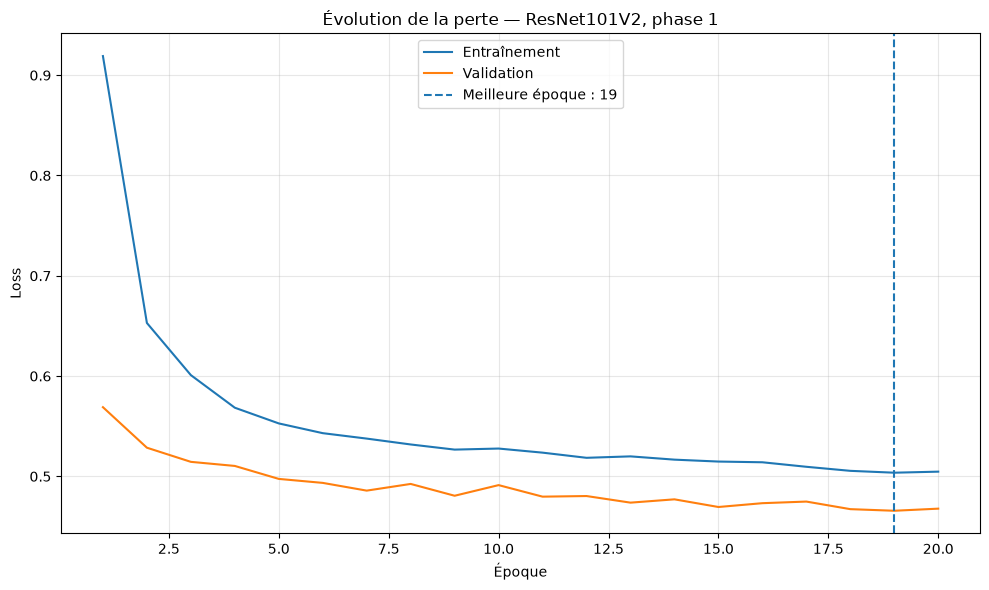

In [47]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution de la perte — ResNet101V2, phase 1")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

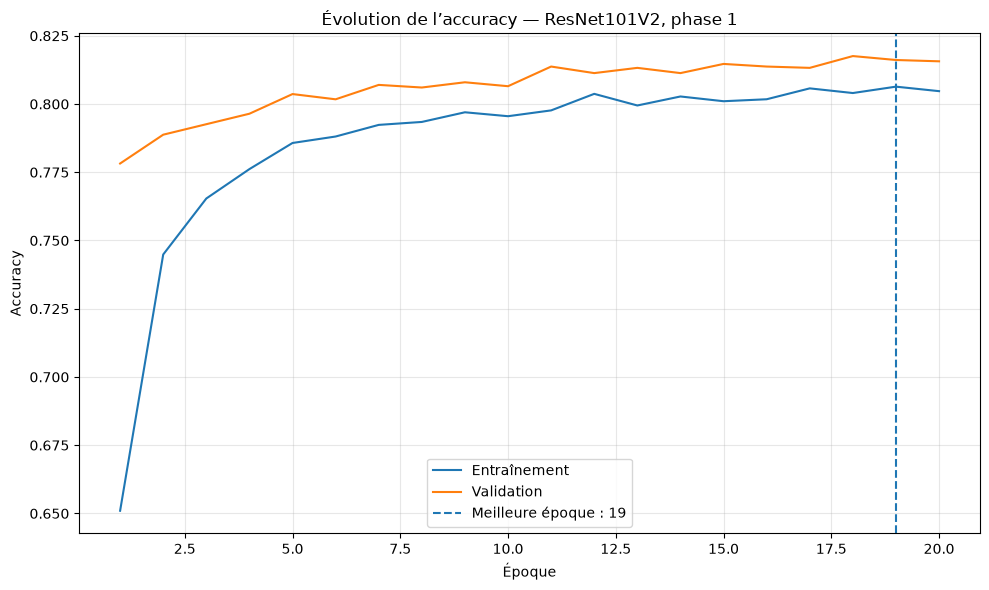

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["accuracy"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_accuracy"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution de l’accuracy — ResNet101V2, phase 1")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
final_train_loss_phase1 = float(
    history_phase1_df["loss"].iloc[-1]
)

final_val_loss_phase1 = float(
    history_phase1_df["val_loss"].iloc[-1]
)

final_train_accuracy_phase1 = float(
    history_phase1_df["accuracy"].iloc[-1]
)

final_val_accuracy_phase1 = float(
    history_phase1_df["val_accuracy"].iloc[-1]
)

print("Dernière époque exécutée :")
print(f"Train loss          : {final_train_loss_phase1:.4f}")
print(f"Validation loss     : {final_val_loss_phase1:.4f}")
print(f"Train accuracy      : {final_train_accuracy_phase1:.4f}")
print(f"Validation accuracy : {final_val_accuracy_phase1:.4f}")

print(
    "\nÉcart d'accuracy train-validation : "
    f"{final_train_accuracy_phase1 - final_val_accuracy_phase1:.4f}"
)


Dernière époque exécutée :
Train loss          : 0.5047
Validation loss     : 0.4678
Train accuracy      : 0.8047
Validation accuracy : 0.8157

Écart d'accuracy train-validation : -0.0109


### Évaluation du modèle après phase 1 sur le jeu de test

Avant le fine-tuning, le modèle obtenu à l'issue de la phase 1 est évalué
sur le jeu de test indépendant.

Cette évaluation servira de référence (baseline) pour comparer les
performances obtenues après le fine-tuning.

Les métriques calculées sont :

- Accuracy
- Balanced Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- Matrice de confusion
- Rapport de classification

In [50]:
# Chargement du meilleur modèle

best_model_phase1 = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("Meilleur modèle ResNet101V2 — phase 1 chargé.")
print("Chemin :", PHASE1_MODEL_PATH)

Meilleur modèle ResNet101V2 — phase 1 chargé.
Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_phase1_best.keras


In [51]:
# Prédiction

y_true_phase1 = []
y_pred_phase1 = []
y_prob_phase1 = []

for images_batch, labels_batch in test_ds:

    probabilities = best_model_phase1.predict(
        images_batch,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true_phase1.extend(labels_batch.numpy())
    y_pred_phase1.extend(predictions)
    y_prob_phase1.extend(probabilities)

y_true_phase1 = np.array(y_true_phase1)
y_pred_phase1 = np.array(y_pred_phase1)
y_prob_phase1 = np.array(y_prob_phase1)

print("Nombre d'images évaluées :", len(y_true_phase1))
print("Forme des probabilités  :", y_prob_phase1.shape)

Nombre d'images évaluées : 2084
Forme des probabilités  : (2084, 4)


In [53]:
# Calcul des métriques

accuracy_phase1 = accuracy_score(
    y_true_phase1,
    y_pred_phase1
)

balanced_accuracy_phase1 = balanced_accuracy_score(
    y_true_phase1,
    y_pred_phase1
)

precision_phase1 = precision_score(
    y_true_phase1,
    y_pred_phase1,
    average="macro",
    zero_division=0
)

recall_phase1 = recall_score(
    y_true_phase1,
    y_pred_phase1,
    average="macro",
    zero_division=0
)

f1_phase1 = f1_score(
    y_true_phase1,
    y_pred_phase1,
    average="macro",
    zero_division=0
)

results_phase1 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy_phase1,
        balanced_accuracy_phase1,
        precision_phase1,
        recall_phase1,
        f1_phase1
    ]
})

results_phase1

,Métrique,Valeur
0,Accuracy,0.814779
1,Balanced Accuracy,0.777825
2,Precision macro,0.810152
3,Recall macro,0.777825
4,F1 macro,0.788979


In [55]:
# Rapport de classification
print("Rapport de classification — ResNet101V2, phase 1\n")
print(
    classification_report(
        y_true_phase1,
        y_pred_phase1,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Rapport de classification — ResNet101V2, phase 1

                 precision    recall  f1-score   support

          COVID     0.7154    0.5223    0.6038       337
   Lung_Opacity     0.8258    0.7596    0.7913       599
         Normal     0.8235    0.9339    0.8752      1014
Viral Pneumonia     0.8759    0.8955    0.8856       134

       accuracy                         0.8148      2084
      macro avg     0.8102    0.7778    0.7890      2084
   weighted avg     0.8100    0.8148    0.8079      2084



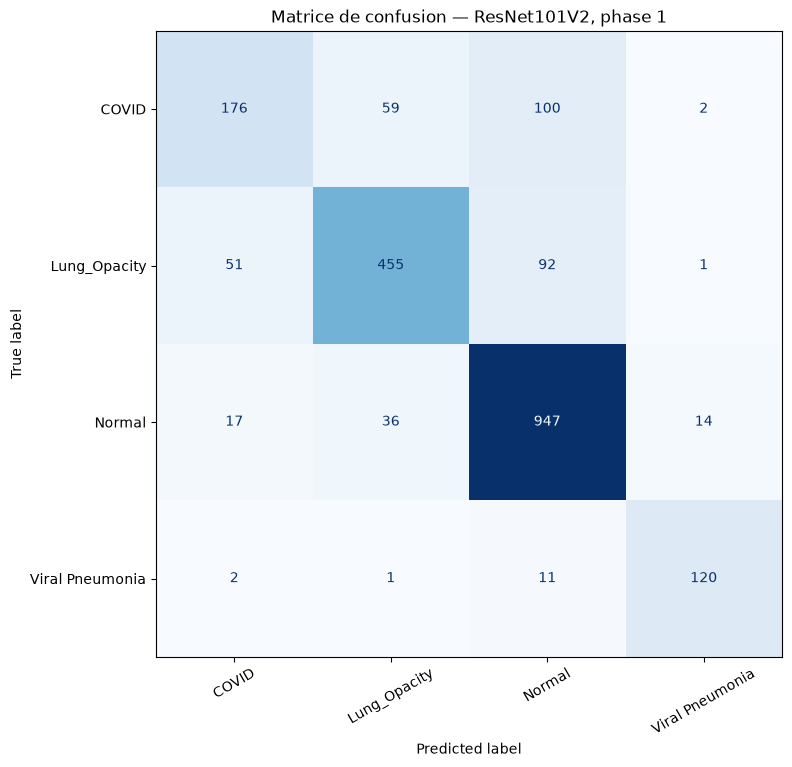

In [56]:
# Matrice de confusion

cm_phase1 = confusion_matrix(
    y_true_phase1,
    y_pred_phase1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_phase1,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Matrice de confusion — ResNet101V2, phase 1"
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [25]:
# Rechargement du meilleur modèle de la phase 1

model = keras.models.load_model(
    PHASE1_MODEL_PATH
)

base_model = model.get_layer(
    "resnet101v2"
)

print("Modèle de phase 1 rechargé.")

Modèle de phase 1 rechargé.


## Phase 2 : Fine Tuning

### Préparation du fine-tuning

Le fine-tuning est réalisé uniquement sur le dernier groupe résiduel de
ResNet101V2, appelé `conv5_x`.

Les couches plus anciennes restent gelées afin de préserver les caractéristiques
génériques apprises sur ImageNet.

In [26]:
# Affichage des 60 dernières couches du backbone

start_index = max(
    0,
    len(base_model.layers) - 60
)

for index in range(
    start_index,
    len(base_model.layers)
):
    layer = base_model.layers[index]

    print(
        f"{index:>3} | "
        f"{layer.name:<35} | "
        f"{layer.__class__.__name__}"
    )

317 | conv4_block21_out                   | Add
318 | conv4_block22_preact_bn             | BatchNormalization
319 | conv4_block22_preact_relu           | Activation
320 | conv4_block22_1_conv                | Conv2D
321 | conv4_block22_1_bn                  | BatchNormalization
322 | conv4_block22_1_relu                | Activation
323 | conv4_block22_2_pad                 | ZeroPadding2D
324 | conv4_block22_2_conv                | Conv2D
325 | conv4_block22_2_bn                  | BatchNormalization
326 | conv4_block22_2_relu                | Activation
327 | conv4_block22_3_conv                | Conv2D
328 | conv4_block22_out                   | Add
329 | conv4_block23_preact_bn             | BatchNormalization
330 | conv4_block23_preact_relu           | Activation
331 | conv4_block23_1_conv                | Conv2D
332 | conv4_block23_1_bn                  | BatchNormalization
333 | conv4_block23_1_relu                | Activation
334 | conv4_block23_2_pad                 | ZeroPadd

In [27]:
# Recherche automatique du début de conv5_x

conv5_start_index = next(
    index
    for index, layer in enumerate(base_model.layers)
    if layer.name.startswith("conv5_block1")
)

print(
    "Indice de début du bloc conv5_x :",
    conv5_start_index
)

print(
    "Première couche du bloc :",
    base_model.layers[
        conv5_start_index
    ].name
)

print(
    "Nombre de couches dans conv5_x :",
    len(base_model.layers)
    - conv5_start_index
)

Indice de début du bloc conv5_x : 341
Première couche du bloc : conv5_block1_preact_bn
Nombre de couches dans conv5_x : 36


In [28]:
# Vérification de l’état actuel

trainable_layers_before = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("État actuel avant fine-tuning")
print("-" * 60)

print(
    "Backbone entraînable :",
    base_model.trainable
)

print(
    "Nombre de couches entraînables :",
    len(trainable_layers_before)
)

État actuel avant fine-tuning
------------------------------------------------------------
Backbone entraînable : False
Nombre de couches entraînables : 1


### Déblocage du dernier bloc résiduel

Le modèle de base est rendu entraînable, mais seules les couches appartenant
au bloc `conv5_x` sont dégelées.

Les couches de normalisation par batch restent gelées afin de préserver leurs
statistiques apprises lors du pré-entraînement sur ImageNet.

In [29]:
# Le backbone devient globalement entraînable
base_model.trainable = True

# Toutes les couches avant conv5_x restent gelées
for layer in base_model.layers[:conv5_start_index]:
    layer.trainable = False

# Dans conv5_x :
# - les BatchNormalization restent gelées
# - toutes les autres couches sont entraînables
for layer in base_model.layers[conv5_start_index:]:

    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

In [30]:
# Vérification des couches entraînables

trainable_layers = [
    layer
    for layer in base_model.layers
    if layer.trainable
]

frozen_layers = [
    layer
    for layer in base_model.layers
    if not layer.trainable
]

print("Backbone entraînable :", base_model.trainable)
print("Couches entraînables :", len(trainable_layers))
print("Couches gelées       :", len(frozen_layers))

print("\nPremières couches entraînables :")
for layer in trainable_layers[:10]:
    print("-", layer.name)

print("\nDernières couches entraînables :")
for layer in trainable_layers[-10:]:
    print("-", layer.name)

Backbone entraînable : True
Couches entraînables : 26
Couches gelées       : 351

Premières couches entraînables :
- conv5_block1_preact_relu
- conv5_block1_1_conv
- conv5_block1_1_relu
- conv5_block1_2_pad
- conv5_block1_2_conv
- conv5_block1_2_relu
- conv5_block1_0_conv
- conv5_block1_3_conv
- conv5_block1_out
- conv5_block2_preact_relu

Dernières couches entraînables :
- conv5_block2_out
- conv5_block3_preact_relu
- conv5_block3_1_conv
- conv5_block3_1_relu
- conv5_block3_2_pad
- conv5_block3_2_conv
- conv5_block3_2_relu
- conv5_block3_3_conv
- conv5_block3_out
- post_relu


In [31]:
# Vérification des BatchNormalization gelées dans conv5_x

bn_trainable = [
    layer.name
    for layer in base_model.layers
    if isinstance(layer, keras.layers.BatchNormalization)
    and layer.trainable
]

print(
    "BatchNormalization entraînables :",
    len(bn_trainable)
)

if len(bn_trainable) == 0:
    print("✓ Toutes les BatchNormalization sont correctement gelées.")
else:
    print("⚠ Attention :")
    print(bn_trainable)

BatchNormalization entraînables : 0
✓ Toutes les BatchNormalization sont correctement gelées.


In [32]:
# Vérification des paramètres après dégel du bloc conv5_x

trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

total_params_phase2 = (
    trainable_params_phase2 +
    non_trainable_params_phase2
)

print(f"Paramètres entraînables     : {trainable_params_phase2:,}")
print(f"Paramètres non entraînables : {non_trainable_params_phase2:,}")
print(f"Paramètres totaux           : {total_params_phase2:,}")

print(
    f"\nPart des paramètres entraînables : "
    f"{100 * trainable_params_phase2 / total_params_phase2:.2f} %"
)

Paramètres entraînables     : 14,958,596
Paramètres non entraînables : 27,676,160
Paramètres totaux           : 42,634,756

Part des paramètres entraînables : 35.09 %


In [33]:
print("Première couche entraînable :")
print(trainable_layers[0].name)

print("\nDernière couche entraînable :")
print(trainable_layers[-1].name)

Première couche entraînable :
conv5_block1_preact_relu

Dernière couche entraînable :
post_relu


### Compilation du modèle pour le fine-tuning

Après le déblocage du dernier bloc résiduel de ResNet101V2, le modèle est recompilé avec un taux d’apprentissage plus faible.

Cette précaution permet d’adapter progressivement les couches pré-entraînées aux radiographies thoraciques sans modifier brutalement les poids appris sur ImageNet.

In [34]:
LEARNING_RATE_PHASE2 = 1e-5

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE2
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle recompilé pour le fine-tuning.")
print(f"Learning rate : {LEARNING_RATE_PHASE2}")

Modèle recompilé pour le fine-tuning.
Learning rate : 1e-05


In [35]:
## Callbacks du fine-tuning

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=PHASE2_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks phase 2 configurés :", len(callbacks_phase2))
for callback in callbacks_phase2:
    print("-", callback.__class__.__name__)

print("\nLe meilleur modèle sera sauvegardé dans :")
print(PHASE2_MODEL_PATH)

Callbacks phase 2 configurés : 3
- ModelCheckpoint
- EarlyStopping
- ReduceLROnPlateau

Le meilleur modèle sera sauvegardé dans :
/mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_finetuning_best.keras


In [37]:
# Vérification avant entraînement

print("État du modèle avant fine-tuning")
print("-" * 50)

print("Modèle de base entraînable :", base_model.trainable)

print(
    "Couches entraînables dans ResNet50 :",
    sum(layer.trainable for layer in base_model.layers)
)

print(
    "Paramètres entraînables du modèle complet :",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

print("Learning rate :", float(model.optimizer.learning_rate.numpy()))

État du modèle avant fine-tuning
--------------------------------------------------
Modèle de base entraînable : True
Couches entraînables dans ResNet50 : 26
Paramètres entraînables du modèle complet : 14,958,596
Learning rate : 9.999999747378752e-06


### Fine-tuning

Le backbone ResNet101V2 est partiellement dégelé.

Seul le dernier groupe résiduel (`conv5_x`) est réentraîné, tandis que les
couches Batch Normalization restent gelées afin de conserver des statistiques
stables.

Le modèle est recompilé avec un faible taux d'apprentissage (`1e-5`) pour
ajuster progressivement les poids pré-entraînés sans dégrader les
représentations apprises sur ImageNet.

In [38]:
EPOCHS_PHASE2 = 20

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

Epoch 1/20


/home/noura/miniforge3/envs/Covid19_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1784542109.254952 1414448 service.cc:153] XLA service 0x7746f4093ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784542109.255046 1414448 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1784542109.629989 1414448 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784542111.833459 1414448 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1784542111.982305 1414448 dot_m

2081/2084 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8249 - loss: 0.4553

I0000 00:00:1784542175.291043 1414451 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25102__.284


2084/2084 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8250 - loss: 0.4551
Epoch 1: val_loss improved from None to 0.38661, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_finetuning_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_finetuning_best.keras
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 99s 38ms/step - accuracy: 0.8250 - loss: 0.4551 - val_accuracy: 0.8469 - val_loss: 0.3866 - learning_rate: 1.0000e-05
Epoch 2/20
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8740 - loss: 0.3326
Epoch 2: val_loss did not improve from 0.38661
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 55s 26ms/step - accuracy: 0.8740 - loss: 0.3326 - val_accuracy: 0.8488 - val_loss: 0.3871 - learning_rate: 1.0000e-05
Epoch 3/20
2082/2084 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9133 - loss: 0.2334
Epoch 3: val_loss improved 

In [40]:
best_epoch_phase2 = (
    np.argmin(history_phase2.history["val_loss"]) + 1
)

best_val_loss_phase2 = np.min(
    history_phase2.history["val_loss"]
)

best_val_accuracy_phase2 = history_phase2.history[
    "val_accuracy"
][best_epoch_phase2 - 1]

print("Fine-tuning terminé.")
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleure val_loss : {best_val_loss_phase2:.4f}")
print(
    f"Meilleure val_accuracy : "
    f"{best_val_accuracy_phase2:.4f}"
)

Fine-tuning terminé.
Meilleure époque : 3
Meilleure val_loss : 0.3738
Meilleure val_accuracy : 0.8651


In [44]:
# Résumé de la phase 2

epochs_completed_phase2 = len(
    history_phase2.history["loss"]
)

best_epoch_phase2 = (
    np.argmin(history_phase2.history["val_loss"]) + 1
)

best_val_loss_phase2 = np.min(
    history_phase2.history["val_loss"]
)

best_val_accuracy_phase2 = history_phase2.history[
    "val_accuracy"
][best_epoch_phase2 - 1]

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleure val_loss : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)
print("Meilleur modèle sauvegardé dans :", PHASE2_MODEL_PATH)

Fine-tuning terminé.
Nombre d'époques exécutées : 8
Meilleure époque : 3
Meilleure val_loss : 0.3738
Val_accuracy à la meilleure époque : 0.8651
Meilleur modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_finetuning_best.keras


In [45]:
# Bilan de la phase 2

history_phase2_df = pd.DataFrame(history_phase2.history)

history_phase2_df.index = np.arange(
    1,
    len(history_phase2_df) + 1
)

history_phase2_df.index.name = "Époque"

history_phase2_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
Époque,,,,,
1,0.824994,0.455133,0.846856,0.386611,1.000000e-05
2,0.874010,0.332579,0.848776,0.387058,1.000000e-05
3,0.913277,0.233464,0.865098,0.373795,1.000000e-05
4,0.944354,0.151232,0.859818,0.460666,1.000000e-05
5,0.967723,0.088030,0.872300,0.486871,1.000000e-05
6,0.988571,0.034908,0.878541,0.542341,2.000000e-06
7,0.994840,0.017221,0.869419,0.659435,2.000000e-06
8,0.997660,0.009799,0.880941,0.621331,4.000000e-07


In [46]:
# Bilan de la phase 2

epochs_completed_phase2 = len(history_phase2_df)

best_epoch_phase2 = (
    history_phase2_df["val_loss"].idxmin()
)

best_val_loss_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_loss"
]

best_val_accuracy_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_accuracy"
]

final_train_loss_phase2 = history_phase2_df[
    "loss"
].iloc[-1]

final_val_loss_phase2 = history_phase2_df[
    "val_loss"
].iloc[-1]

final_train_accuracy_phase2 = history_phase2_df[
    "accuracy"
].iloc[-1]

final_val_accuracy_phase2 = history_phase2_df[
    "val_accuracy"
].iloc[-1]

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleure val_loss : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)

print("\nDernière époque exécutée :")
print(f"Train loss      : {final_train_loss_phase2:.4f}")
print(f"Validation loss : {final_val_loss_phase2:.4f}")
print(f"Train accuracy      : {final_train_accuracy_phase2:.4f}")
print(f"Validation accuracy : {final_val_accuracy_phase2:.4f}")

Fine-tuning terminé.
Nombre d'époques exécutées : 8
Meilleure époque : 3
Meilleure val_loss : 0.3738
Val_accuracy à la meilleure époque : 0.8651

Dernière époque exécutée :
Train loss      : 0.0098
Validation loss : 0.6213
Train accuracy      : 0.9977
Validation accuracy : 0.8809


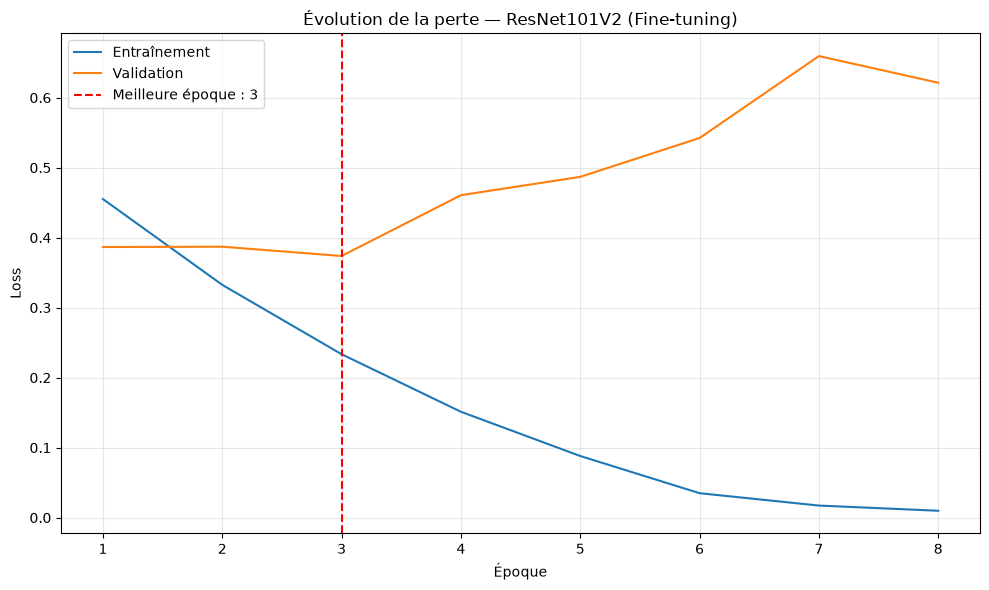

In [47]:
# Courbe de la perte - Phase 2 (Fine-tuning)

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    linewidth=1.5,
    color="red",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution de la perte — ResNet101V2 (Fine-tuning)")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

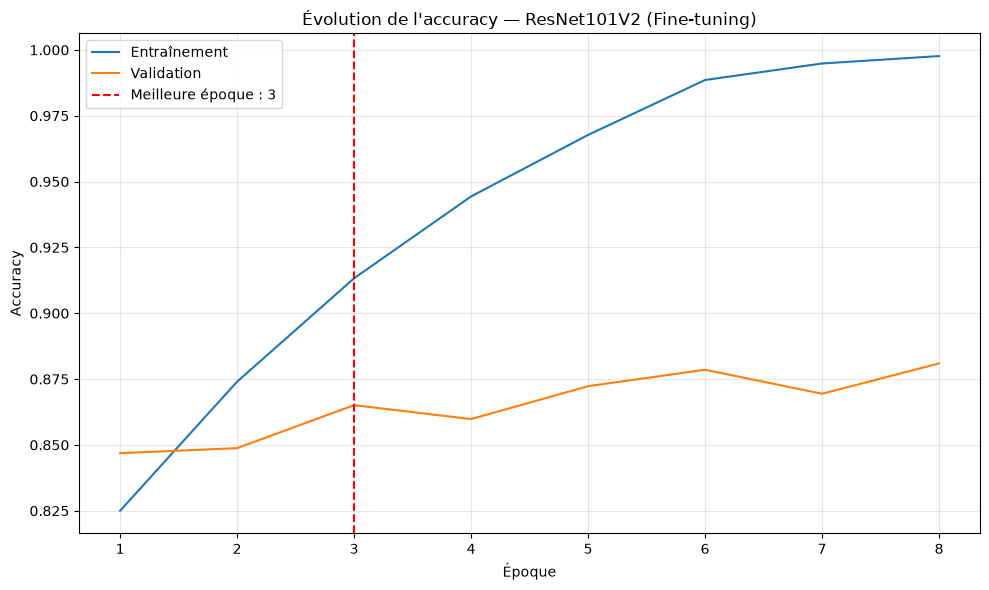

In [48]:
# Courbe de l'accuracy - Phase 2 (Fine-tuning)

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["accuracy"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_accuracy"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    linewidth=1.5,
    color="red",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution de l'accuracy — ResNet101V2 (Fine-tuning)")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Évaluation finale du modèle fine-tuné

Le meilleur modèle obtenu pendant le fine-tuning est chargé depuis le fichier
de sauvegarde.

L’évaluation est ensuite réalisée sur le jeu de test indépendant, qui n’a pas
été utilisé pour entraîner le modèle ni pour sélectionner la meilleure époque.

In [49]:
# Chargement du meilleur modèle après fine-tuning

best_model_phase2 = keras.models.load_model(
    PHASE2_MODEL_PATH
)

print("Meilleur modèle Fine-tuning chargé.")
print("Chemin :", PHASE2_MODEL_PATH)

Meilleur modèle Fine-tuning chargé.
Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet101v2_unbalanced/resnet101v2_finetuning_best.keras


In [50]:
# Vérification rapide avec evaluate
# Cette première évaluation fournit la perte et l’accuracy, mais nous allons ensuite calculer toutes les métriques détaillées.

test_loss_phase2, test_accuracy_phase2 = (
    best_model_phase2.evaluate(
        test_ds,
        verbose=1
    )
)

print("\nRésultats sur le jeu de test")
print(f"Test loss     : {test_loss_phase2:.4f}")
print(f"Test accuracy : {test_accuracy_phase2:.4f}")

131/131 ━━━━━━━━━━━━━━━━━━━━ 24s 136ms/step - accuracy: 0.8700 - loss: 0.3759

Résultats sur le jeu de test
Test loss     : 0.3759
Test accuracy : 0.8700


In [51]:
# Génération des prédictions

y_true_phase2 = []
y_pred_phase2 = []
y_prob_phase2 = []

for images_batch, labels_batch in test_ds:

    probabilities = best_model_phase2.predict(
        images_batch,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true_phase2.extend(labels_batch.numpy())
    y_pred_phase2.extend(predictions)
    y_prob_phase2.extend(probabilities)

y_true_phase2 = np.array(y_true_phase2)
y_pred_phase2 = np.array(y_pred_phase2)
y_prob_phase2 = np.array(y_prob_phase2)

print("Nombre d'images :", len(y_true_phase2))
print("Shape des probabilités :", y_prob_phase2.shape)

Nombre d'images : 2084
Shape des probabilités : (2084, 4)


In [52]:
# Calcul des métriques finales

accuracy_phase2 = accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

balanced_accuracy_phase2 = balanced_accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

precision_phase2 = precision_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

recall_phase2 = recall_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

f1_phase2 = f1_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

results_phase2 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

results_phase2

,Métrique,Valeur
0,Accuracy,0.869962
1,Balanced Accuracy,0.866362
2,Precision macro,0.860468
3,Recall macro,0.866362
4,F1 macro,0.862096


In [53]:
# Rapport de classification
print("Rapport phase_2")
print(
    classification_report(
        y_true_phase2,
        y_pred_phase2,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Rapport phase_2
                 precision    recall  f1-score   support

          COVID     0.7404    0.8042    0.7710       337
   Lung_Opacity     0.8996    0.7930    0.8429       599
         Normal     0.8953    0.9280    0.9114      1014
Viral Pneumonia     0.9065    0.9403    0.9231       134

       accuracy                         0.8700      2084
      macro avg     0.8605    0.8664    0.8621      2084
   weighted avg     0.8722    0.8700    0.8698      2084



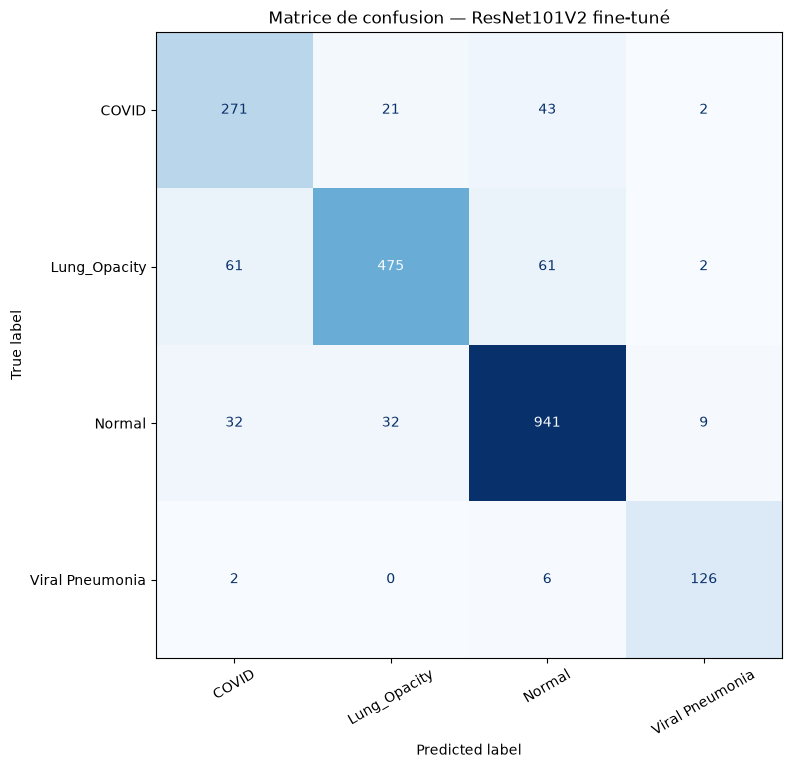

In [54]:
# Matrice de confusion

cm_phase2 = confusion_matrix(
    y_true_phase2,
    y_pred_phase2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_phase2,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Matrice de confusion — ResNet101V2 fine-tuné")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Interprétabilité du modèle avec Grad-CAM

Grad-CAM permet de visualiser les régions de l’image ayant le plus contribué
à la prédiction du modèle.

La carte d’activation est calculée à partir de la dernière sortie
convolutionnelle de ResNet50, puis superposée à la radiographie originale.

In [55]:
# Vérifier la couche utilisée

resnet_base = best_model_phase2.get_layer("resnet101v2")

print("Nom du modèle de base :", resnet_base.name)
print("Forme de sa sortie    :", resnet_base.output.shape)
print("Dernière couche       :", resnet_base.layers[-1].name)

Nom du modèle de base : resnet101v2
Forme de sa sortie    : (None, 7, 7, 2048)
Dernière couche       : post_relu


In [56]:
# Fonction de restauration de l'image

def deprocess_resnet101v2(image):
    """
    Restaure une image prétraitée avec
    tf.keras.applications.resnet_v2.preprocess_input
    afin de pouvoir l'afficher en RGB.
    """
    image = image.numpy().copy()

    # Réintégration des moyennes ImageNet en ordre BGR
    image[..., 0] += 103.939
    image[..., 1] += 116.779
    image[..., 2] += 123.680

    # Conversion BGR vers RGB
    image = image[..., ::-1]

    return np.clip(image, 0, 255).astype("uint8")

In [57]:
# Construction des sous-modèles nécessaires pour Grad-CAM

# Modèle ResNet101V2 imbriqué dans le modèle complet
resnet_base = best_model_phase2.get_layer(
    "resnet101v2"
)

# Dernière couche convolutionnelle pertinente de ResNet101V2
LAST_CONV_LAYER_NAME = "conv5_block3_out"

last_conv_layer = resnet_base.get_layer(
    LAST_CONV_LAYER_NAME
)

# Sous-modèle :
# image -> dernière carte convolutionnelle
#       + sortie finale du backbone ResNet101V2
conv_model = keras.Model(
    inputs=resnet_base.inputs,
    outputs=[
        last_conv_layer.output,
        resnet_base.output
    ],
    name="resnet101v2_gradcam"
)

print("Modèle de base             :", resnet_base.name)
print("Couche Grad-CAM            :", last_conv_layer.name)
print(
    "Sortie convolutionnelle    :",
    last_conv_layer.output.shape
)
print(
    "Sortie ResNet101V2         :",
    resnet_base.output.shape
)

Modèle de base             : resnet101v2
Couche Grad-CAM            : conv5_block3_out
Sortie convolutionnelle    : (None, 7, 7, 2048)
Sortie ResNet101V2         : (None, 7, 7, 2048)


In [58]:
def deprocess_resnet101v2(image):
    """
    Restaure une image prétraitée avec
    tf.keras.applications.resnet_v2.preprocess_input.

    Le prétraitement transforme les pixels
    de [0, 255] vers [-1, 1].
    """
    image = image.numpy().copy()

    # Passage de [-1, 1] vers [0, 255]
    image = (image + 1.0) * 127.5

    return np.clip(
        image,
        0,
        255
    ).astype("uint8")

In [60]:
# Construction des deux sous-modèles nécessaires pour Grad-CAM

# Entrée correspondant à la sortie de ResNet101V2
classifier_input = keras.Input(
    shape=resnet_base.output_shape[1:],
    name="classifier_input"
)

x = classifier_input

# Application des couches situées après ResNet101V2
resnet_layer_index = best_model_phase2.layers.index(
    resnet_base
)

for layer in best_model_phase2.layers[
    resnet_layer_index + 1:
]:
    x = layer(x)

classifier_model = keras.Model(
    inputs=classifier_input,
    outputs=x,
    name="classification_head"
)

classifier_model.summary()

Model: "classification_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,196 (32.02 KB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# fonction Grad-CAM

def make_gradcam_heatmap(
    image_batch,
    conv_model,
    classifier_model,
    class_index=None
):
    """
    Calcule une carte Grad-CAM pour le modèle ResNet101V2 imbriqué.
    """

    with tf.GradientTape() as tape:

        # Cartes convolutives et sortie finale du ResNet101V2
        conv_outputs, resnet_features = conv_model(
            image_batch,
            training=False
        )

        # Nécessaire pour calculer le gradient par rapport aux activations
        tape.watch(conv_outputs)

        # Passage dans la tête de classification
        predictions = classifier_model(
            resnet_features,
            training=False
        )

        if class_index is None:
            class_index = tf.argmax(
                predictions[0]
            )

        class_score = predictions[
            :,
            class_index
        ]

    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    if gradients is None:
        raise RuntimeError(
            "Les gradients n'ont pas pu être calculés."
        )

    # Importance moyenne de chaque canal
    channel_weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    feature_maps = conv_outputs[0]

    # Somme pondérée des cartes d'activation
    heatmap = tf.reduce_sum(
        feature_maps * channel_weights,
        axis=-1
    )

    # Grad-CAM conserve les contributions positives
    heatmap = tf.nn.relu(heatmap)

    # Normalisation entre 0 et 1
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return (
        heatmap.numpy(),
        predictions[0].numpy(),
        int(class_index.numpy())
    )

In [62]:
# Fonction de superposition

def overlay_gradcam(
    original_image,
    heatmap,
    alpha=0.4
):
    """
    Superpose une carte Grad-CAM à l'image originale.
    """

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        size=original_image.shape[:2]
    ).numpy().squeeze()

    # Transformation de la heatmap en image colorée
    colored_heatmap = plt.get_cmap("jet")(
        heatmap_resized
    )[..., :3]

    colored_heatmap = (
        colored_heatmap * 255
    ).astype("uint8")

    superimposed_image = (
        (1 - alpha) * original_image
        + alpha * colored_heatmap
    )

    return np.clip(
        superimposed_image,
        0,
        255
    ).astype("uint8")

In [63]:
def display_gradcam_grid(
    dataset,
    model,
    conv_model,
    classifier_model,
    class_names,
    n_images=12,
    only_errors=False
):
    """
    Affiche plusieurs images avec leur Grad-CAM.

    Parameters
    ----------
    dataset : tf.data.Dataset
        Dataset prétraité pour ResNet101V2.
    model : keras.Model
        Modèle complet fine-tuné.
    conv_model : keras.Model
        Sous-modèle fournissant les activations convolutionnelles.
    classifier_model : keras.Model
        Tête de classification.
    class_names : list[str]
        Noms des classes.
    n_images : int
        Nombre maximal d'images à afficher.
    only_errors : bool
        Si True, affiche uniquement les prédictions incorrectes.
    """

    selected = []

    for images_batch, labels_batch in dataset:

        probabilities_batch = model.predict(
            images_batch,
            verbose=0
        )

        predictions_batch = np.argmax(
            probabilities_batch,
            axis=1
        )

        for image_tensor, true_label, pred_label, probabilities in zip(
            images_batch,
            labels_batch.numpy(),
            predictions_batch,
            probabilities_batch
        ):
            is_error = int(true_label) != int(pred_label)

            if only_errors and not is_error:
                continue

            selected.append({
                "image_tensor": image_tensor,
                "true_label": int(true_label),
                "pred_label": int(pred_label),
                "probabilities": probabilities
            })

            if len(selected) >= n_images:
                break

        if len(selected) >= n_images:
            break

    if not selected:
        print("Aucune image correspondant au critère.")
        return

    fig, axes = plt.subplots(
        len(selected),
        2,
        figsize=(10, 4 * len(selected))
    )

    if len(selected) == 1:
        axes = np.array([axes])

    for row, item in enumerate(selected):

        image_tensor = item["image_tensor"]
        true_label = item["true_label"]
        pred_label = item["pred_label"]
        probabilities = item["probabilities"]

        image_batch = tf.expand_dims(
            image_tensor,
            axis=0
        )

        heatmap, _, predicted_class_index = (
            make_gradcam_heatmap(
                image_batch=image_batch,
                conv_model=conv_model,
                classifier_model=classifier_model
            )
        )

        original_image = deprocess_resnet101v2(
            image_tensor
        )

        gradcam_image = overlay_gradcam(
            original_image,
            heatmap,
            alpha=0.4
        )

        confidence = float(
            probabilities[predicted_class_index]
        )

        true_name = class_names[true_label]
        pred_name = class_names[pred_label]

        status = (
            "Correct"
            if true_label == pred_label
            else "Erreur"
        )

        axes[row, 0].imshow(original_image)
        axes[row, 0].set_title(
            f"Image originale\n"
            f"Classe réelle : {true_name}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gradcam_image)
        axes[row, 1].set_title(
            f"{status}\n"
            f"Prédiction : {pred_name}\n"
            f"Confiance : {confidence:.1%}"
        )
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

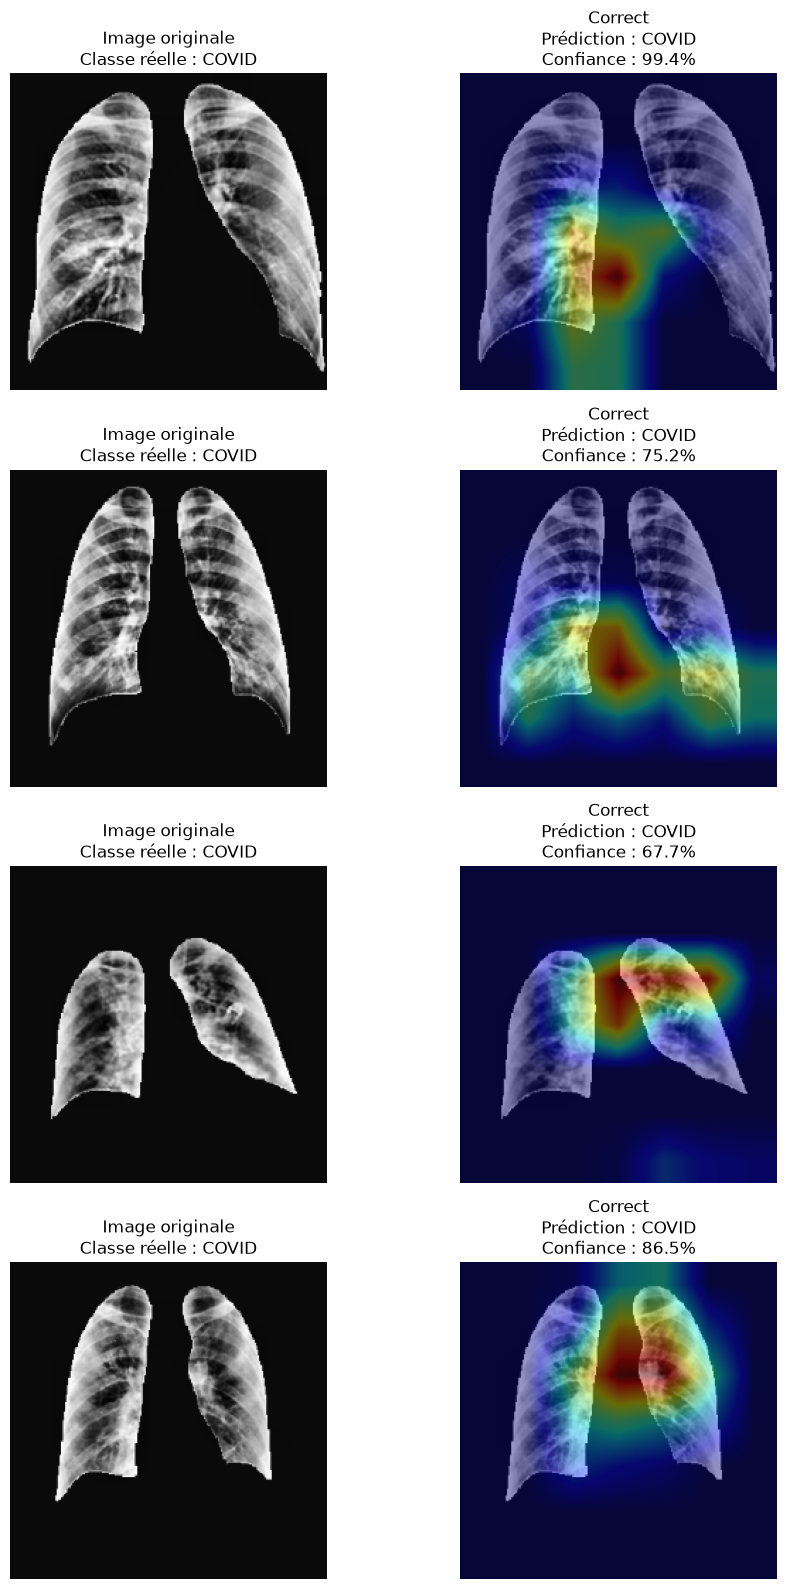

In [64]:
display_gradcam_grid(
    dataset=test_ds,
    model=best_model_phase2,
    conv_model=conv_model,
    classifier_model=classifier_model,
    class_names=class_names,
    n_images=4,
    only_errors=False
)

# Conclusion

## Synthèse

Cette section rassemble l'ensemble des résultats obtenus avec le modèle
fine-tuné.

Les performances sont évaluées à l'aide de plusieurs métriques adaptées
à un problème de classification multiclasse déséquilibré :

- Accuracy
- Balanced Accuracy
- Precision macro
- Recall macro
- F1-score macro

Les résultats sont ensuite comparés à ceux obtenus avant le fine-tuning.

In [74]:
# Tableau comparatif Phase 1 / Phase 2

comparison_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],

    "Phase 1": [
        accuracy_phase1,
        balanced_accuracy_phase1,
        precision_phase1,
        recall_phase1,
        f1_phase1
    ],

    "Fine-tuning": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

comparison_results["Gain"] = (
    comparison_results["Fine-tuning"]
    - comparison_results["Phase 1"]
)

comparison_results["Gain (%)"] = (
    comparison_results["Gain"] * 100
)

comparison_results = comparison_results.round({
    "Phase 1": 4,
    "Fine-tuning": 4,
    "Gain": 4,
    "Gain (%)": 2
})

comparison_results

,Métrique,Phase 1,Fine-tuning,Gain,Gain (%)
0,Accuracy,0.8148,0.8700,0.0552,5.52
1,Balanced Accuracy,0.7778,0.8664,0.0885,8.85
2,Precision macro,0.8102,0.8605,0.0503,5.03
3,Recall macro,0.7778,0.8664,0.0885,8.85
4,F1 macro,0.7890,0.8621,0.0731,7.31


In [ ]:
# Tableau formaté en %

comparison_display = comparison_results.copy()

for col in ["Phase 1", "Fine-tuning", "Gain"]:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).map(lambda x: f"{x:.2f} %")

comparison_display

,Métrique,Phase 1,Fine-tuning,Gain,Gain (%)
0,Accuracy,81.48 %,87.00 %,0.0552,5.52
1,Balanced Accuracy,77.78 %,86.64 %,0.0885,8.85
2,Precision macro,81.02 %,86.05 %,0.0503,5.03
3,Recall macro,77.78 %,86.64 %,0.0885,8.85
4,F1 macro,78.90 %,86.21 %,0.0731,7.31


## Bénéfice du Fine Tuning

Cette dernière section résume automatiquement les performances obtenues et
l'apport du fine-tuning.

Les conclusions sont calculées directement à partir des résultats du modèle.

In [78]:
# Calcul des gains apportés par le fine-tuning
# Les valeurs sont exprimées en points de pourcentage

gain_accuracy = (
    accuracy_phase2 - accuracy_phase1
) * 100

gain_f1 = (
    f1_phase2 - f1_phase1
) * 100

gain_balanced = (
    balanced_accuracy_phase2
    - balanced_accuracy_phase1
) * 100

print("=" * 70)
print("CONCLUSION DU MODÈLE RESNET101V2")
print("=" * 70)

print()

print("Performances finales sur le jeu de test")

print(
    f"Accuracy            : {accuracy_phase2:.4f}"
)

print(
    f"Balanced Accuracy   : {balanced_accuracy_phase2:.4f}"
)

print(
    f"F1-score macro      : {f1_phase2:.4f}"
)

print()

print("Apport du fine-tuning par rapport à la phase 1")

print(
    f"Accuracy       : {gain_accuracy:+.2f} point(s)"
)

print(
    f"Balanced Acc.  : {gain_balanced:+.2f} point(s)"
)

print(
    f"F1 macro       : {gain_f1:+.2f} point(s)"
)

print()

print(
    "Le modèle final retenu est le modèle ResNet101V2 "
    "fine-tuné correspondant à la meilleure val_loss "
    "et sauvegardé par le callback ModelCheckpoint."
)

print("=" * 70)

CONCLUSION DU MODÈLE RESNET101V2

Performances finales sur le jeu de test
Accuracy            : 0.8700
Balanced Accuracy   : 0.8664
F1-score macro      : 0.8621

Apport du fine-tuning par rapport à la phase 1
Accuracy       : +5.52 point(s)
Balanced Acc.  : +8.85 point(s)
F1 macro       : +7.31 point(s)

Le modèle final retenu est le modèle ResNet101V2 fine-tuné correspondant à la meilleure val_loss et sauvegardé par le callback ModelCheckpoint.
